# Урок 1. Основные показатели розничной торговли и описательная статистика

## Курс
**«Анализ данных и статистика в розничной торговле одеждой на Python: от данных к управленческому решению»**

### Цель урока

Научиться правильно описывать показатели розничной сети **до применения статистических критериев**.

В этом уроке мы работаем только на уровне **всей сети** и рассматриваем 9 основных KPI:

1. Выручка
2. Посетители
3. Чеки
4. Покупки
5. Конверсия
6. Длина чека
7. Средняя цена
8. Средний чек
9. Выручка на посетителя

Мы разберём:

- абсолютные и расчётные показатели;
- среднее и взвешенное среднее;
- медиану;
- дисперсию;
- стандартное отклонение;
- коэффициент вариации;
- правильную агрегацию KPI;
- сезонность;
- месячные коэффициенты сезонности;
- fashion-сезоны **S** и **W**;
- динамику показателей по сезонам;
- долю S и W в выручке и посетителях.

> Важный принцип курса: сначала понять экономический смысл показателя и правила его расчёта, а уже потом применять статистические методы.

## 1. Исходная учебная база

Мы используем синтетическую сеть из 50 магазинов одежды.

Период наблюдений:

- январь 2022 — август 2026;
- 56 месяцев;
- 50 магазинов.

Исходный файл:

`Retail_50_Stores_Synthetic_v1.xlsx`

Для анализа используем лист:

`Данные_long`

На первом уроке **не сравниваем отдельные магазины**. Сначала агрегируем данные до уровня всей сети.

In [1]:
# Импорт основных библиотек для работы с данными и визуализацией.
# pandas — таблицы и временные ряды,
# numpy  — числовые операции,
# matplotlib.pyplot — графики.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Имя входного файла. В реальном проекте лучше вынести в переменную окружения
# или параметр командной строки, но для ноутбука — нормально.
FILE = "Retail_50_Stores_Synthetic_v1.xlsx"

# Читаем Excel-файл.
# sheet_name="Данные_long" — берём конкретный лист, название на русском.
# "long" в названии листа намекает на «длинный» формат данных (long format):
# каждая строка — это наблюдение (магазин × месяц × товар/метрика),
# в отличие от «широкого» формата, где метрики были бы разложены по столбцам.
df = pd.read_excel(FILE, sheet_name="Данные_long")

# Преобразуем столбец "Месяц" в тип datetime.
# Это критично для временных рядов: без этого нельзя будет
# делать ресемплинг, брать .dt-атрибуты, строить графики по датам и т.д.
# Если в файле даты уже сохранены как даты Excel — pandas их распознает,
# если как строки — to_datetime их распарсит.
df["Месяц"] = pd.to_datetime(df["Месяц"])

# Печатаем минимальную и максимальную дату в данных.
# .min().date() и .max().date() убирают время, оставляя только дату,
# чтобы вывод был компактным. Это даёт понимание, какой период покрыт датасетом.
print("Период:", df["Месяц"].min().date(), "—", df["Месяц"].max().date())

# Считаем число уникальных магазинов.
# nunique() возвращает количество уникальных значений в столбце "Магазин".
# По названию файла ожидается 50 магазинов — полезно сразу проверить.
print("Магазинов:", df["Магазин"].nunique())

# Общее число строк в датафрейме.
# Помогает оценить масштаб данных: например, 50 магазинов × 24 месяца × N товаров.
print("Строк:", len(df))

# Показываем первые 5 строк, транспонированные (.T).
# Зачем .T: при большом числе столбцов горизонтальная таблица не влезает
# в экран ноутбука, и столбцы «уезжают» вправо. В транспонированном виде
# названия столбцов становятся строками, и все они видны вертикально.
# display — функция Jupyter/IPython для красивого вывода.
display(df.head().T)

Период: 2022-01-01 — 2026-08-01
Магазинов: 50
Строк: 2800


,0,1,2,3,4
Месяц,2022-01-01 00:00:00,2022-01-01 00:00:00,2022-01-01 00:00:00,2022-01-01 00:00:00,2022-01-01 00:00:00
Город,Город1,Город1,Город1,Город1,Город1
Магазин,Магазин1,Магазин2,Магазин3,Магазин4,Магазин5
План,3191594,1659761,2283147,1865602,2324944
Выручка,3897749,1385729,2052870,1956684,2035011
ВыручкаБезАкс,3682172,1295129,1960650,1765007,1866329
ВыручкаАкс,215577,90600,92220,191677,168682
Посетители,10694,6295,5785,4300,4478
Чеки,638,220,238,351,243
ПокупокБезАкс,1277,300,457,569,512


## Что делает код в целом
Импортирует библиотеки для анализа данных и визуализации.

Загружает Excel-файл с листа "Данные_long" в DataFrame df.

Приводит столбец "Месяц" к типу datetime — это обязательный шаг для любого временного анализа.

Выводит три ключевые метрики:

диапазон дат (период, покрытый данными);

количество уникальных магазинов;

общее число строк.

Показывает первые 5 строк в транспонированном виде — удобный способ быстро увидеть все столбцы и типы данных.

## Зачем это нужно (типичный первый шаг EDA)
Это «шаг 0» любого анализа временных рядов в ритейле:

Период определяет, сколько сезонов/циклов в данных, есть ли достаточно истории для модели.

Число магазинов задаёт панельную структуру: 50 магазинов × T месяцев × M товаров.

Число строк позволяет быстро прикинуть масштаб и оценить, потянет ли ноутбук дальнейшие операции.

.head().T даёт моментальное представление о схеме данных: какие столбцы есть, какие значения в них, какие типы.



## 2. Девять основных показателей сети

Четыре показателя являются **абсолютными**:

Выручка,Посетители,Чеки,Покупки
Их можно суммировать по магазинам и периодам.

Например:
$$Выручка_{янв-фев}=Выручка_{янв}+Выручка_{фев}$$

Пять других KPI являются **расчётными**:

$$Конверсия = \frac{Чеки}{Посетители}$$
$$Длина\ чека = \frac{Покупки}{Чеки}$$
$$Средняя\ цена = \frac{Выручка}{Покупки}$$
$$Средний\ чек = \frac{Выручка}{Чеки}$$
$$Выручка\ на\ посетителя = \frac{Выручка}{Посетители}$$

Их нельзя просто складывать и, как правило, нельзя агрегировать простым средним.

Полезно также при анализе представлять 

$$Средний\ чек = {Длина\ чека}*{Средняя\ цена}$$

$$Выручка\ на\ посетителя = {Конверсия}*{Длина\ чека}*{Средняя\ цена}$$

$$Выручка = {Посетители}*{Конверсия}*{Длина\ чека}*{Средняя\ цена}$$

Выражение для выручки показывает , что план по выручке на самом деле представляет собой произведение планов по четырем показателям
и при анализе его выполнения мы анализируем выполнение плана по каждому показателю.


## 3. Формируем месячные показатели всей сети

Сначала суммируем абсолютные показатели по всем 50 магазинам.

После этого рассчитываем относительные KPI **заново из агрегированных числителей и знаменателей**.

In [2]:
# --- Сетевая витрина метрик по месяцам ---
# Цель блока — собрать агрегированные по всей сети магазинов показатели
# в разрезе месяцев: суммируем абсолютные метрики и вычисляем производные.

# Группируем исходный длинный DataFrame по столбцу "Месяц".
# as_index=False — ключевой параметр: без него "Месяц" стал бы индексом
# результата, а с ним остаётся обычным столбцом (удобнее для дальнейших
# операций, вывода и объединений).
network = (
    df.groupby("Месяц", as_index=False)
      # Named aggregation: для каждого агрегата явно указываем
      # (исходный столбец, функция) и имя результирующего столбца.
      .agg(
          Выручка=("Выручка", "sum"),        # суммарная выручка сети за месяц
          Посетители=("Посетители", "sum"),  # суммарный трафик за месяц
          Чеки=("Чеки", "sum"),              # суммарное число чеков
          Покупки=("Покупок", "sum")         # суммарное число купленных единиц
      )
)

# --- Производные (относительные) метрики ---
# Все считаются построчно (по каждому месяцу) как отношения уже
# просуммированных абсолютных показателей.
# Это даёт корректные сетевые метрики: отношение сумм, а не среднее отношений.

# Конверсия: доля посетителей, оформивших чек. Обычно 0..1.
network["Конверсия"] = network["Чеки"] / network["Посетители"]

# Длина чека: сколько единиц товара в среднем в одном чеке.
network["Длина чека"] = network["Покупки"] / network["Чеки"]

# Средняя цена: средняя цена одной единицы товара.
network["Средняя цена"] = network["Выручка"] / network["Покупки"]

# Средний чек: средняя сумма одного чека.
network["Средний чек"] = network["Выручка"] / network["Чеки"]

# Выручка на посетителя (revenue per visitor, ARPU-подобная метрика):
# сколько денег приносит один посетитель в среднем.
network["Выручка на посетителя"] = network["Выручка"] / network["Посетители"]

# Список метрик для дальнейшего анализа (графики, корреляции, модели).
# Порядок: сначала абсолютные, затем относительные — так удобнее читать.
METRICS = [
    "Выручка",
    "Посетители",
    "Чеки",
    "Покупки",
    "Конверсия",
    "Длина чека",
    "Средняя цена",
    "Средний чек",
    "Выручка на посетителя",
]


# --- Форматирование вывода через Styler ---
# Функции ниже форматируют ТОЛЬКО отображение таблицы.
# Сами значения в network остаются числами — это важно для расчётов и графиков.

def fmt_month(x):
    """Timestamp -> '2022-01'."""
    # Если значение пропущено — вернуть пустую строку,
    # чтобы Styler не падал на NaT.
    if pd.isna(x):
        return ""
    # strftime с шаблоном %Y-%m даёт строку вида "2022-01".
    return x.strftime("%Y-%m")

def fmt_int(x):
    """Целое с пробелом как разделителем разрядов: 1234567 -> '1 234 567'."""
    if pd.isna(x):
        return ""
    # round + int: аккуратно избавляемся от дробной части.
    # f"{n:,}" вставляет запятые как разделитель (1,234,567),
    # затем заменяем их на пробел — получаем "1 234 567".
    return f"{int(round(x)):,}".replace(",", " ")

def fmt_pct(x):
    """Доля -> проценты с одним знаком: 0.1234 -> '12.3%'."""
    if pd.isna(x):
        return ""
    # Умножаем на 100, чтобы перевести долю в проценты,
    # .1f даёт один знак после запятой.
    return f"{x * 100:.1f}%"

def fmt_dec2(x):
    """Десятичное с двумя знаками: 3.4567 -> '3.46'."""
    if pd.isna(x):
        return ""
    # .2f — ровно два знака после запятой, округление стандартное (банковское на float).
    return f"{x:.2f}"

# Словарь соответствия "имя столбца -> функция форматирования".
# Логика разбиения:
#   - Месяц: как "YYYY-MM";
#   - абсолютные и денежные метрики — целые с разделителем разрядов;
#   - Конверсия — проценты с одним знаком;
#   - Длина чека — два знака после запятой (там важны доли).
format_map = {
    "Месяц": fmt_month,
    "Выручка": fmt_int,
    "Посетители": fmt_int,
    "Чеки": fmt_int,
    "Покупки": fmt_int,
    "Средняя цена": fmt_int,
    "Средний чек": fmt_int,
    "Выручка на посетителя": fmt_int,
    "Конверсия": fmt_pct,
    "Длина чека": fmt_dec2,
}

# --- Финальный рендер таблицы через Styler ---
(
    network
    .style                            # создаём Styler поверх DataFrame
    .format(format_map)               # применяем формат по столбцам из словаря
    .set_caption("Сетевые метрики по месяцам")  # заголовок таблицы
    .set_properties(**{"text-align": "right"})  # выравнивание значений вправо
    .set_table_styles([               # тонкая настройка заголовка таблицы
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),     # разместить заголовок над таблицей
                ("font-weight", "bold"),     # сделать его жирным
            ]
        }
    ])
)

,Месяц,Выручка,Посетители,Чеки,Покупки,Конверсия,Длина чека,Средняя цена,Средний чек,Выручка на посетителя
0,2022-01,159 041 802,328 891,22 415,58 788,6.8%,2.62,2 705,7 095,484
1,2022-02,139 369 828,272 619,21 243,59 249,7.8%,2.79,2 352,6 561,511
2,2022-03,174 155 312,356 055,23 442,60 252,6.6%,2.57,2 890,7 429,489
3,2022-04,187 135 342,333 476,24 973,67 470,7.5%,2.70,2 774,7 494,561
4,2022-05,202 800 090,356 601,27 317,82 529,7.7%,3.02,2 457,7 424,569
5,2022-06,169 952 680,344 119,26 449,80 860,7.7%,3.06,2 102,6 426,494
6,2022-07,143 800 906,309 406,26 360,78 338,8.5%,2.97,1 836,5 455,465
7,2022-08,164 891 053,378 894,28 884,83 872,7.6%,2.90,1 966,5 709,435
8,2022-09,194 656 834,372 959,26 110,69 613,7.0%,2.67,2 796,7 455,522
9,2022-10,253 855 687,394 636,29 704,72 734,7.5%,2.45,3 490,8 546,643


# 4. Почему нельзя просто усреднять конверсию?

Рассмотрим условный пример.

| Месяц | Посетители | Чеки | Конверсия |
|---|---:|---:|---:|
| Январь | 10 000 | 1 000 | 10% |
| Февраль | 20 000 | 1 600 | 8% |

Наивное среднее:


$$\frac{10\% + 8\%}{2}=9\%$$

Но правильная конверсия за два месяца:

$$\frac{1000+1600}{10000+20000}=8.67\%$$

Почему возникла разница?

Потому что месяцы имеют разный объём посетителей.

Фактически итоговая конверсия является **взвешенным средним месячных конверсий**, где весом выступает количество посетителей.

In [3]:
# Создаём маленький синтетический DataFrame для иллюстрации.
# Два месяца с разным трафиком и числом чеков.
# Подчёркивания в числах (10_000) — синтаксический сахар Python 3.6+,
# визуально отделяют разряды, значение то же, что 10000.
example = pd.DataFrame({
    "Месяц": ["Январь", "Февраль"],
    "Посетители": [10_000, 20_000],
    "Чеки": [1_000, 1_600]
})

# Считаем конверсию для каждого месяца отдельно:
#   Январь:  1000 / 10000 = 0.10 = 10%
#   Февраль: 1600 / 20000 = 0.08 = 8%
# Это построчная (per-row) метрика — доля чеков от посетителей в конкретном месяце.
example["Конверсия"] = example["Чеки"] / example["Посетители"]

# --- Три разных способа "усреднить" конверсию ---

# 1) ПРОСТОЕ СРЕДНЕЕ: (10% + 8%) / 2 = 9%.
# Складываем конверсии двух месяцев и делим на 2.
# Ошибка: месяцы считаются равнозначными, хотя во втором трафик в 2 раза больше.
# Именно это обычно называют "наивным средним".
simple_mean = example["Конверсия"].mean()

# 2) ПРАВИЛЬНАЯ КОНВЕРСИЯ ЗА ДВА МЕСЯЦА:
#   (1000 + 1600) / (10000 + 20000) = 2600 / 30000 ≈ 0.0867 = 8.67%.
# Сначала суммируем числители и знаменатели, потом делим.
# Это "отношение сумм" — корректная агрегированная метрика за период.
correct_conversion = example["Чеки"].sum() / example["Посетители"].sum()

# 3) ВЗВЕШЕННОЕ СРЕДНЕЕ:
#   Σ(конверсия_i × вес_i) / Σ(вес_i), где вес — Посетители.
# Численно совпадает с (2), потому что:
#   Σ(Чеки_i / Посетители_i × Посетители_i) / ΣПосетители_i
#     = ΣЧеки_i / ΣПосетители_i.
# То есть взвешивание конверсий по трафику даёт ту же цифру, что и отношение сумм.
# np.average — функция NumPy: принимает массив значений и массив весов.
weighted_mean = np.average(
    example["Конверсия"],
    weights=example["Посетители"]
)

# Показываем исходную таблицу (в Jupyter отрисуется красиво).
display(example)

# Печатаем три числа в процентах с двумя знаками после запятой.
# Формат .2% сам умножает на 100 и добавляет знак %.
print(f"Простое среднее: {simple_mean:.2%}")            # 9.00%
print(f"Правильная конверсия: {correct_conversion:.2%}")  # 8.67%
print(f"Взвешенное среднее: {weighted_mean:.2%}")       # 8.67%

,Месяц,Посетители,Чеки,Конверсия
0,Январь,10000,1000,0.10
1,Февраль,20000,1600,0.08


Простое среднее: 9.00%
Правильная конверсия: 8.67%
Взвешенное среднее: 8.67%


## 5. Универсальное правило агрегирования расчётных KPI

Если показатель является отношением:

$$KPI=\frac{Числитель}{Знаменатель}$$

то для объединённого периода правильнее считать:

$$KPI_{итого}=\frac{\sum Числитель}{\sum Знаменатель}$$

а не:

$$\frac{KPI_1+KPI_2+\dots+KPI_n}{n}$$

Для наших показателей:

| KPI | Правильный расчёт за период |
|---|---|
| Конверсия | Σ Чеки / Σ Посетители |
| Длина чека | Σ Покупки / Σ Чеки |
| Средняя цена | Σ Выручка / Σ Покупки |
| Средний чек | Σ Выручка / Σ Чеки |
| Выручка на посетителя | Σ Выручка / Σ Посетители |

Это одно из важнейших правил практической розничной аналитики.

# 6. Среднее и взвешенное среднее

## Арифметическое среднее

Для набора наблюдений:

$$x_1,x_2,\dots,x_n$$

арифметическое среднее:


$$\bar{x}=\frac{x_1+x_2+\dots+x_n}{n}$$


Оно отвечает на вопрос:

> Каков средний уровень показателя на одно наблюдение?

Например, средняя месячная выручка сети.

## Взвешенное среднее

Если наблюдения имеют разный вес:


$$\bar{x}_w=\frac{\sum w_i x_i}{\sum w_i}$$


В розничной торговле веса часто возникают естественно:

- для конверсии — посетители;
- для длины чека — чеки;
- для средней цены — покупки;
- для среднего чека — чеки;
- для выручки на посетителя — посетители.

## 7. «Средняя месячная конверсия» и «конверсия за весь период» — разные вопросы

Это принципиально важно.

### Средняя месячная конверсия


$$\frac{Conversion_{Jan}+...+Conversion_{Dec}}{12}$$

каждый месяц имеет одинаковый вес.

### Конверсия сети за весь период

$$\frac{\sum Чеки}{\sum Посетители}$$


месяцы с большим числом посетителей имеют больший вес.

Оба расчёта могут быть корректными, но они отвечают **на разные аналитические вопросы**.

Этот фрагмент — практическое применение того, что мы обсуждали на синтетическом примере: сравнение простого среднего конверсии по месяцам и конверсии за весь период (отношение сумм).

## Какую метрику использовать
period_conversion — правильная, когда вопрос звучит как «какая у нас была конверсия за первое полугодие», «какой был средний чек за квартал», «какова конверсия по сети в целом». Это то, что обычно имеют в виду в бизнес-отчётах.

mean_monthly_conversion — иногда осмысленна, когда вопрос звучит как «в каком среднем месяце какая у нас конверсия». Но и тогда лучше смотреть на медиану или взвешенное среднее, потому что простое среднее чувствительно к выбросам и к месяцам с аномально низким/высоким трафиком.

In [4]:
# --- Простое среднее конверсии по месяцам ---
# network["Конверсия"] — это Series с конверсией за каждый месяц
# (уже посчитанной как Чеки / Посетители внутри месяца).
# .mean() складывает все месячные конверсии и делит на число месяцев.
# ВАЖНО: этот способ считает все месяцы равнозначными,
# независимо от того, сколько в них было трафика.
# Это "наивное среднее" — оно почти всегда отличается от реальной
# конверсии за период и часто даёт смещённую оценку.
mean_monthly_conversion = network["Конверсия"].mean()

# --- Правильная конверсия за весь период ---
# Сначала суммируем числители (все чеки за все месяцы),
# затем суммируем знаменатели (все посетители за все месяцы),
# и только потом делим одно на другое.
# Это "отношение сумм" — корректная агрегированная метрика
# для метрик-отношений (конверсия, средний чек, средняя цена и т.п.).
# Эквивалентно взвешенному среднему месячных конверсий по числу посетителей.
period_conversion = (
    network["Чеки"].sum()
    / network["Посетители"].sum()
)

# --- Вывод результатов в процентах с двумя знаками после запятой ---
# Формат .2% автоматически умножает на 100 и добавляет знак "%".
print(f"Средняя месячная конверсия: {mean_monthly_conversion:.2%}")
print(f"Конверсия за весь период:   {period_conversion:.2%}")

Средняя месячная конверсия: 8.05%
Конверсия за весь период:   7.97%


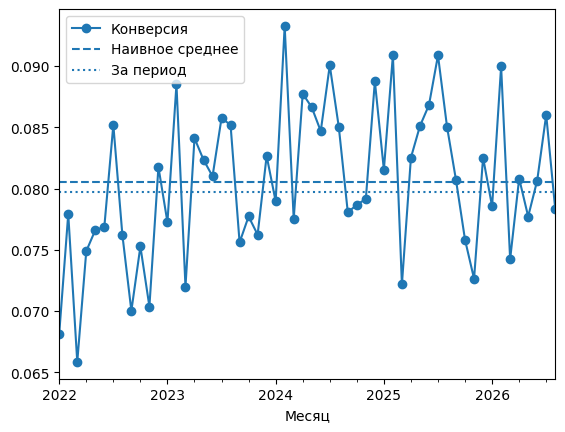

In [5]:
#Визуализацию — как меняется конверсия по месяцам и где находится среднее:
ax = network.plot(x="Месяц", y="Конверсия", marker="o")
ax.axhline(mean_monthly_conversion, linestyle="--", label="Наивное среднее")
ax.axhline(period_conversion, linestyle=":", label="За период")
ax.legend()

# 8. Медиана

Медиана — значение, которое делит упорядоченный ряд пополам:

- 50% наблюдений ниже медианы;
- 50% выше.

Если распределение симметрично и без сильных выбросов, среднее и медиана часто близки.

Если имеются сильные пики, выбросы или асимметрия, они могут заметно различаться.

В розничной торговле это особенно актуально из-за:

- декабрьских пиков;
- распродаж;
- временных закрытий;
- аномально сильных месяцев;
- структурных изменений.

Этот блок строит сравнительную таблицу среднего и медианы по всем сетевым метрикам и показывает, насколько среднее отличается от медианы в процентах — это быстрый способ оценить скошенность распределения каждой метрики.

In [6]:
# Строим сводную таблицу: для каждой метрики из списка METRICS
# считаем два показателя — среднее и медиану по месяцам.
# network[METRICS] — это подтаблица только с нужными столбцами,
# .mean() и .median() возвращают Series, индексированные именами метрик.
# pd.DataFrame({...}) собирает их в один DataFrame, где:
#   индекс строки — имя метрики,
#   столбцы — "Среднее" и "Медиана".
mean_median = pd.DataFrame({
    "Среднее": network[METRICS].mean(),
    "Медиана": network[METRICS].median()
})

# Считаем относительное отклонение среднего от медианы в процентах:
#   (Среднее / Медиана - 1) * 100
# Смысл метрики:
#   > 0  — среднее выше медианы (распределение скошено вправо, есть крупные "хвосты");
#   < 0  — среднее ниже медианы (скос влево, есть аномально низкие значения);
#   ≈ 0  — распределение примерно симметричное, среднее и медиана близки.
# Умножение на 100 переводит долю в проценты — удобнее читать.
mean_median["Разница_%_от_медианы"] = (
    mean_median["Среднее"] / mean_median["Медиана"] - 1
) * 100

# Показываем таблицу, округляя все числа до 3 знаков после запятой.
# Округление — только для отображения, сами значения в mean_median не меняются.
display(mean_median.round(3))

,Среднее,Медиана,Разница_%_от_медианы
Выручка,1.849288e+08,1.765649e+08,4.737
Посетители,2.807303e+05,2.777395e+05,1.077
Чеки,2.238784e+04,2.254000e+04,-0.675
Покупки,6.370945e+04,6.225300e+04,2.340
Конверсия,8.100000e-02,8.100000e-02,-0.186
Длина чека,2.856000e+00,2.851000e+00,0.195
Средняя цена,2.955257e+03,2.898076e+03,1.973
Средний чек,8.358878e+03,8.303317e+03,0.669
Выручка на посетителя,6.713390e+02,6.609180e+02,1.577


## Что делает код в целом
Собирает среднее и медиану по всем метрикам из METRICS в один DataFrame.

Вычисляет относительную разницу между средним и медианой в процентах. Это безразмерная метрика, позволяющая сравнивать признаки с разными масштабами (например, Выручка в миллионах и Конверсия в долях).

Выводит результат, округлённый до трёх знаков — для читаемости

## Как интерпретировать результат
Разница_%_от_медианы ≈ 0 — распределение симметричное, среднее и медиана почти совпадают.

Разница_%_от_медианы > 0 — правый скос (положительная асимметрия): есть месяцы с аномально высокими значениями, они «тянут» среднее вверх. Медиана устойчивее и лучше отражает типичное значение.

Разница_%_от_медианы < 0 — левый скос: есть аномально низкие значения (например, «провальные» месяцы), они «тянут» среднее вниз.

Большая разница (например, > 20–30%) — сигнал, что среднее как метрика «типичного» значения ненадёжно. В отчётах стоит показывать медиану или обе цифры.

Для метрик-отношений (Конверсия, Средний чек, Длина чека, Средняя цена) интерпретация сложнее: эти значения сами по себе — агрегаты, и их «среднее по месяцам» — это наивное среднее, а не реальная метрика за период. Разница тут показывает разброс между месяцами, но не «правильность» среднего.

# 9. Дисперсия, стандартное отклонение и коэффициент вариации

Среднее показывает **уровень** показателя.

Но два ряда с одинаковым средним могут иметь совершенно разную стабильность.

## Дисперсия


$$s^2=\frac{\sum(x_i-\bar{x})^2}{n-1}$$


## Стандартное отклонение

$$s=\sqrt{s^2}$$


Оно показывает характерный масштаб отклонения наблюдений от среднего.

Но стандартные отклонения показателей с разными единицами измерения нельзя напрямую сравнивать.

Например:

- выручка измеряется в рублях;
- посетители — в людях;
- конверсия — в долях.

Поэтому для сравнения изменчивости разных KPI полезен **коэффициент вариации**.

## 10. Коэффициент вариации


$$CV=\frac{s}{\bar{x}}\times100\%$$


Он показывает размер стандартного отклонения относительно среднего уровня показателя.

Чем выше CV, тем сильнее относительная изменчивость показателя.

> Важно: CV — описательная характеристика. Высокий CV сам по себе не говорит, хорошо это или плохо для бизнеса. Сначала нужно понять причины изменчивости.

Этот блок строит расширенную описательную статистику по всем сетевым метрикам и добавляет коэффициент вариации (CV) — безразмерную меру разброса, позволяющую сравнивать метрики с разными масштабами.

In [22]:
# Собираем описательные статистики по всем метрикам из METRICS
# в один DataFrame. Каждый вызов метода возвращает Series,
# индексированный именами метрик, — их объединяем в столбцы.
descriptive = pd.DataFrame({
    # Среднее арифметическое по месяцам: Σx / n.
    # Чувствительно к выбросам, хорошо работает для симметричных распределений.
    "Среднее": network[METRICS].mean(),

    # Медиана — 50-й процентиль: значение, которое делит выборку пополам.
    # Устойчива к выбросам и скошенности, отражает "типичное" значение.
    "Медиана": network[METRICS].median(),

    # Дисперсия — средний квадрат отклонения от среднего.
    # ddof=1 — "выборочная" дисперсия (делим на n-1, а не на n).
    # Это корректная оценка для выборки, а не для генеральной совокупности.
    # Важно: pandas по умолчанию использует ddof=1, но указание явно — хорошая практика.
    "Дисперсия": network[METRICS].var(ddof=1),

    # Стандартное отклонение — корень из дисперсии.
    # Возвращает разброс в тех же единицах, что и исходная метрика,
    # поэтому интерпретируется легче, чем дисперсия (которая в квадрате единиц).
    "Стандартное отклонение": network[METRICS].std(ddof=1),
})

# Добавляем Коэффициент вариации (CV, coefficient of variation):
#   CV = σ / μ
# Безразмерная мера относительного разброса. Позволяет сравнивать
# "шумность" метрик с разными масштабами (например, Выручку в рублях
# и Конверсию в долях). Чем больше CV, тем сильнее метрика "гуляет".

descriptive["CV_%"] = (
    descriptive["Стандартное отклонение"]
    / descriptive["Среднее"]*100
 )

#Форматирование. Для читаемого вывода применяем Styler
(
    descriptive
    .style
    .format({
        "Среднее": "{:,.3f}",
        "Медиана": "{:,.3f}",
        "Дисперсия": "{:,.0f}",
        "Стандартное отклонение": "{:,.3f}",
        "CV_%": "{:.1f}%",
    })
    .set_caption("Описательные статистики сетевых метрик")
)



,Среднее,Медиана,Дисперсия,Стандартное отклонение,CV_%
Выручка,"184,928,829.768","176,564,870.000","1,852,987,908,043,054","43,046,346.048",23.3%
Посетители,"280,730.268","277,739.500","4,505,375,505","67,122.094",23.9%
Чеки,"22,387.839","22,540.000","22,201,649","4,711.863",21.0%
Покупки,"63,709.446","62,253.000","175,031,807","13,229.959",20.8%
Конверсия,0.081,0.081,0,0.006,7.7%
Длина чека,2.856,2.851,0,0.200,7.0%
Средняя цена,"2,955.257","2,898.076","383,486",619.262,21.0%
Средний чек,"8,358.878","8,303.317","1,986,503","1,409.434",16.9%
Выручка на посетителя,671.339,660.918,"12,825",113.248,16.9%


## Что делает код в целом
Собирает четыре описательные статистики по каждой метрике:

среднее — центр распределения;

медиана — устойчивый центр;

дисперсия — квадратичный разброс;

стандартное отклонение — разброс в исходных единицах.

Вычисляет коэффициент вариации — относительный разброс в процентах, позволяющий сравнивать метрики с разными масштабами.

Выводит таблицу, округлённую до трёх знаков

## Как интерпретировать результат
Среднее vs Медиана — та же логика, что и в предыдущем блоке: расхождение говорит о скошенности.

Дисперсия — полезна для математических выкладок (например, при сложении независимых величин дисперсии складываются), но плохо читается «на глаз», потому что её размерность — квадрат исходной.

Стандартное отклонение — «типичное» отклонение от среднего в единицах метрики:

для Выручки — в рублях;

для Конверсии — в долях (например, σ = 0.02 означает ±2 п.п.);

для Среднего чека — в рублях.

CV_% — универсальная мера относительной изменчивости. Грубые ориентиры:

< 10% — низкая вариабельность, метрика стабильна;

10–25% — умеренная;

25–50% — высокая;

> 50% — очень высокая (часто признак сильной сезонности или нестабильности процесса).

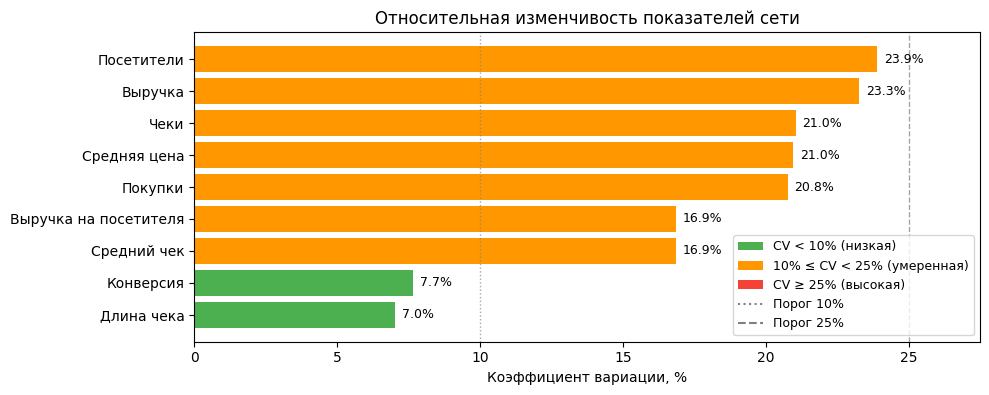

In [23]:
# Этот блок строит горизонтальную столбчатую диаграмму коэффициентов вариации (CV) по всем сетевым метрикам,
#отсортированных по возрастанию — наглядный способ сразу увидеть, какие показатели самые «шумные», а какие — стабильные.
# Берём столбец CV_% из таблицы descriptive и сортируем по возрастанию.
# sort_values() без аргументов сортирует по значениям (не по индексу).
# Получаем Series, где индекс — имена метрик, значения — CV в процентах,
# отсортированные от самых стабильных к самым изменчивым.
# --- Подготовка данных ---
# Берём CV_% из descriptive и сортируем по возрастанию:
# от самых стабильных метрик к самым изменчивым.
cv = descriptive["CV_%"].sort_values()

# --- Цветовая кодировка по уровню изменчивости ---
# Ориентиры (эвристика из практики):
#   CV < 10%   — низкая вариабельность  → зелёный
#   10–25%     — умеренная              → оранжевый
#   ≥ 25%      — высокая                → красный
def cv_color(value):
    if value < 10:
        return "#4caf50"   # зелёный
    elif value < 25:
        return "#ff9800"   # оранжевый
    return "#f44336"       # красный

colors = [cv_color(v) for v in cv.values]

# --- Построение графика ---
fig, ax = plt.subplots(figsize=(10, max(4, len(cv) * 0.45)))

# Горизонтальные столбцы с индивидуальным цветом.
# y = cv.index (названия метрик), width = cv.values (значения CV в %).
ax.barh(cv.index, cv.values, color=colors)

# Вертикальные линии пороговых значений CV.
# Пунктир / штрих-пунктир / сплошная — чтобы визуально различались.
for threshold, style, label in [
    (10, ":",  "10% — низкая / умеренная"),
    (25, "--", "25% — умеренная / высокая"),
]:
    ax.axvline(
        threshold,
        linestyle=style,
        color="gray",
        alpha=0.7,
        linewidth=1
    )

# Подписи значений прямо на столбцах:
# чуть правее конца столбца, по центру по вертикали.
# x_offset подобран так, чтобы текст не наезжал на столбец.
x_max = cv.values.max()
x_offset = x_max * 0.01
for i, (name, value) in enumerate(cv.items()):
    ax.text(
        value + x_offset,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9,
        color="black"
    )

# --- Подписи осей и заголовок ---
ax.set_xlabel("Коэффициент вариации, %")
ax.set_title("Относительная изменчивость показателей сети")

# Небольшой запас справа, чтобы подписи значений не упирались в край.
ax.set_xlim(0, x_max * 1.15)

# --- Легенда ---
# Собираем кастомные «ручки» для легенды: цвета + линии порогов.
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor="#4caf50", label="CV < 10% (низкая)"),
    Patch(facecolor="#ff9800", label="10% ≤ CV < 25% (умеренная)"),
    Patch(facecolor="#f44336", label="CV ≥ 25% (высокая)"),
    Line2D([0], [0], color="gray", linestyle=":",  label="Порог 10%"),
    Line2D([0], [0], color="gray", linestyle="--", label="Порог 25%"),
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=9,
    frameon=True
)

# Автоматическая подгонка отступов, чтобы подписи не обрезались.
plt.tight_layout()
plt.show()

## Что делает код в целом
Берёт столбец CV_% из таблицы descriptive (построенной в предыдущем блоке).

Сортирует метрики по возрастанию CV — от самых стабильных к самым изменчивым.

Строит горизонтальную столбчатую диаграмму, где:

по оси Y — названия метрик,

по оси X — значение CV в процентах,

длина столбца визуально кодирует изменчивость.

## Как читать график
Короткие столбцы внизу — метрики со стабильной динамикой. Например, Посетители или Чеки часто имеют низкий CV, если трафик по месяцам примерно ровный.

Длинные столбцы вверху — метрики с высокой изменчивостью. Часто это Конверсия или Средний чек — они сильнее реагируют на сезонность, акции, поведение покупателей.

Порядок сортировки помогает мгновенно выделить «проблемные» метрики — те, что скачут от месяца к месяцу.

Сравнение метрик между собой корректно именно потому, что CV безразмерен: Выручка в рублях и Конверсия в долях оказываются на одной шкале.

### Вопрос для анализа

Какие KPI наиболее стабильны?

Какие имеют высокую вариативность?

Не спешите трактовать высокий CV как проблему. В дальнейшем мы увидим, что значительная часть вариативности может иметь **систематическую сезонную природу**.

# 11. Экономическая архитектура показателей сети

Наши KPI связаны между собой.


$$Средний\ чек=Средняя\ цена\timesДлина\ чека$$


Действительно:

$$\frac{Выручка}{Чеки}=\frac{Выручка}{Покупки}\times\frac{Покупки}{Чеки}$$


Ещё более важное равенство:


$$Выручка\ на\ посетителя=Конверсия\times Длина\ чека\times Средняя\ цена$$


И в итоге:

$$Выручка=Посетители\timesКонверсия\timesДлина\ чека\timesСредняя\ цена$$


Это базовая факторная модель розничной сети.

In [25]:
#Этот блок — проверка корректности декомпозиции выручки: он пересчитывает ключевые метрики «с нуля» из множителей и
#сравнивает с исходными значениями в network.
# Делаем копию network, чтобы не портить исходный DataFrame.
# Все новые столбцы добавляем в копию — оригинал остаётся нетронутым.
check = network.copy()

# --- Проверка 1: средний чек ---
# По определению: Средний чек = Выручка / Чеки.
# Но также справедливо тождество:
#   Средний чек = (Выручка / Покупки) × (Покупки / Чеки)
#               = Средняя цена   × Длина чека.
# Пересчитываем средний чек через произведение двух факторов
# и сравниваем с исходным network["Средний чек"].
check["Средний чек из факторов"] = (
    check["Средняя цена"] * check["Длина чека"]
)

# --- Проверка 2: выручка на посетителя ---
# По определению: Выручка на посетителя = Выручка / Посетители.
# Разложим через цепочку отношений:
#   Выручка / Посетители
#     = (Чеки / Посетители) × (Покупки / Чеки) × (Выручка / Покупки)
#     = Конверсия × Длина чека × Средняя цена.
# Снова сравниваем с исходным значением.
check["Выручка на посетителя из факторов"] = (
    check["Конверсия"]
    * check["Длина чека"]
    * check["Средняя цена"]
)

# --- Проверка 3: выручка ---
# По определению: Выручка = Посетители × (Выручка / Посетители).
# Подставляя разложение выручки на посетителя:
#   Выручка = Посетители × Конверсия × Длина чека × Средняя цена.
# Это классическая мультипликативная декомпозиция:
#   Выручка = Трафик × Конверсия × Длина чека × Средняя цена.
check["Выручка из факторов"] = (
    check["Посетители"]
    * check["Конверсия"]
    * check["Длина чека"]
    * check["Средняя цена"]
)

# Показываем первые 5 строк с нужными столбцами в удобном порядке:
# для каждой исходной метрики рядом стоит её "факторная" версия,
# чтобы визуально убедиться, что значения совпадают.
display(
    check[
        [
            "Месяц",
            "Средний чек",
            "Средний чек из факторов",
            "Выручка на посетителя",
            "Выручка на посетителя из факторов",
            "Выручка",
            "Выручка из факторов",
        ]
    ].head()
)

,Месяц,Средний чек,Средний чек из факторов,Выручка на посетителя,Выручка на посетителя из факторов,Выручка,Выручка из факторов
0,2022-01-01,7095.329110,7095.329110,483.569943,483.569943,159041802,159041802.0
1,2022-02-01,6560.741327,6560.741327,511.225659,511.225659,139369828,139369828.0
2,2022-03-01,7429.200239,7429.200239,489.124748,489.124748,174155312,174155312.0
3,2022-04-01,7493.506667,7493.506667,561.165847,561.165847,187135342,187135342.0
4,2022-05-01,7423.951752,7423.951752,568.703088,568.703088,202800090,202800090.0


In [8]:
check = network.copy()

check["Средний чек из факторов"] = (
    check["Средняя цена"] * check["Длина чека"]
)

check["Выручка на посетителя из факторов"] = (
    check["Конверсия"]
    * check["Длина чека"]
    * check["Средняя цена"]
)

check["Выручка из факторов"] = (
    check["Посетители"]
    * check["Конверсия"]
    * check["Длина чека"]
    * check["Средняя цена"]
)

display(
    check[
        [
            "Месяц",
            "Средний чек",
            "Средний чек из факторов",
            "Выручка на посетителя",
            "Выручка на посетителя из факторов",
            "Выручка",
            "Выручка из факторов",
        ]
    ].head()
)

,Месяц,Средний чек,Средний чек из факторов,Выручка на посетителя,Выручка на посетителя из факторов,Выручка,Выручка из факторов
0,2022-01-01,7095.329110,7095.329110,483.569943,483.569943,159041802,159041802.0
1,2022-02-01,6560.741327,6560.741327,511.225659,511.225659,139369828,139369828.0
2,2022-03-01,7429.200239,7429.200239,489.124748,489.124748,174155312,174155312.0
3,2022-04-01,7493.506667,7493.506667,561.165847,561.165847,187135342,187135342.0
4,2022-05-01,7423.951752,7423.951752,568.703088,568.703088,202800090,202800090.0


## Зачем вообще такая проверка
Убедиться в корректности ETL-пайплайна. Если все метрики посчитаны правильно, декомпозиция сойдётся. Любое расхождение — баг.

Подготовить факторный анализ. Когда разложение подтверждено, можно отвечать на вопросы вида «почему выручка упала в марте»:

упал ли трафик (Посетители);

упала ли конверсия;

уменьшилась ли длина чека;

снизилась ли средняя цена.
Каждое из этих изменений вносит вклад в итоговое изменение выручки.

# 12. Динамика KPI во времени

Теперь посмотрим на показатели сети с января 2022 по август 2026 года.

Временная динамика позволяет увидеть:

- рост или снижение;
- сезонные пики;
- повторяющийся рисунок;
- нестабильные периоды;
- возможные структурные изменения.

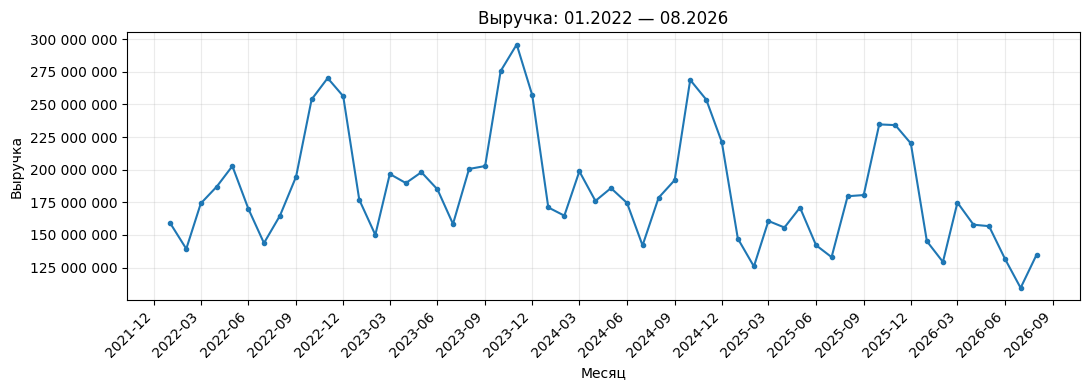

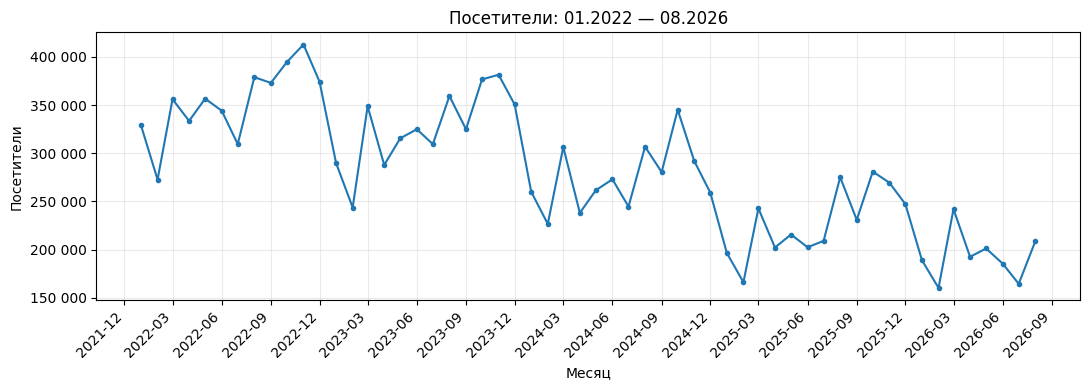

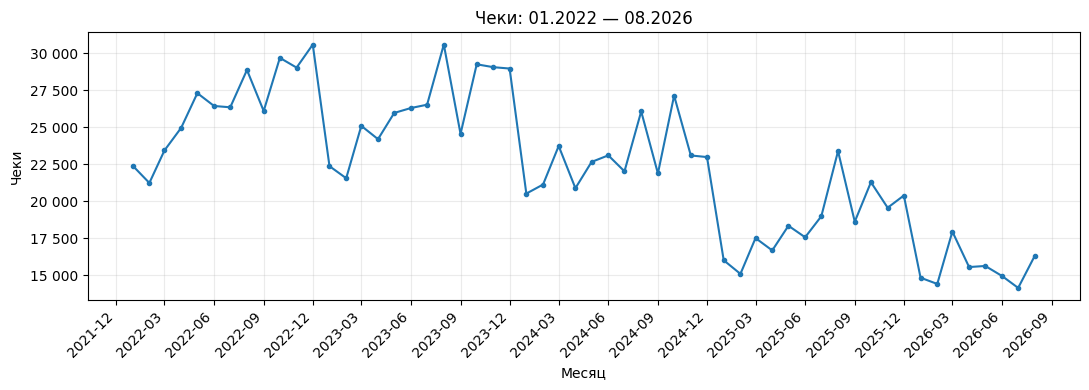

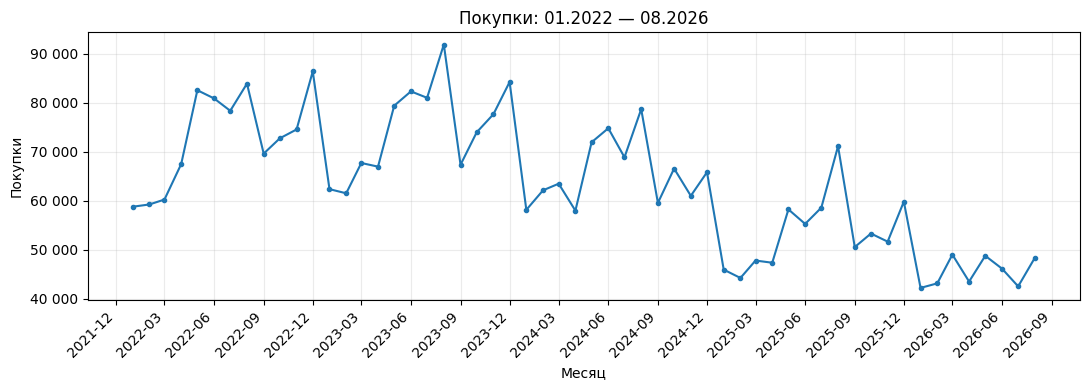

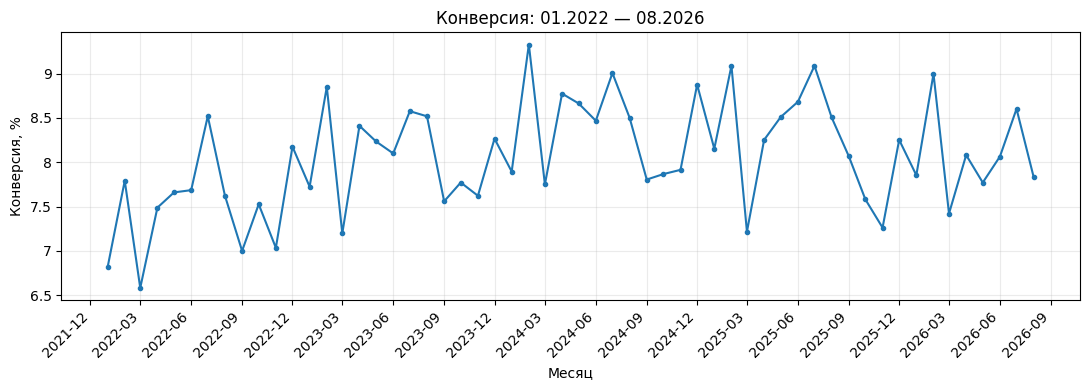

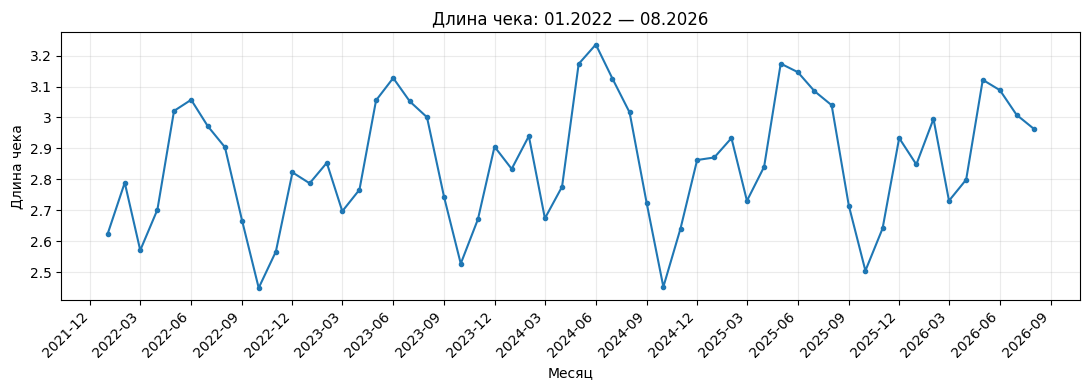

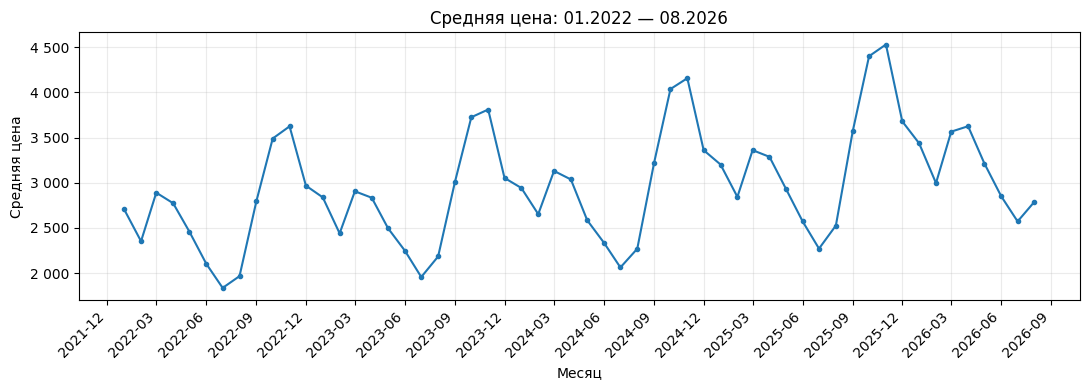

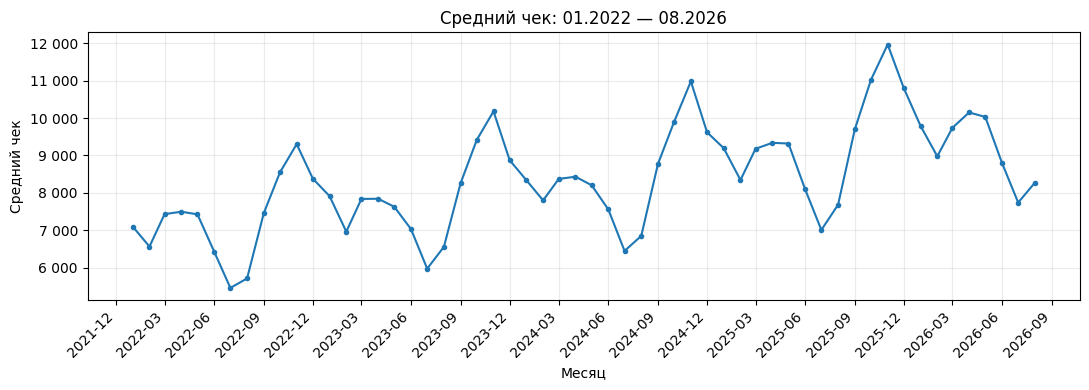

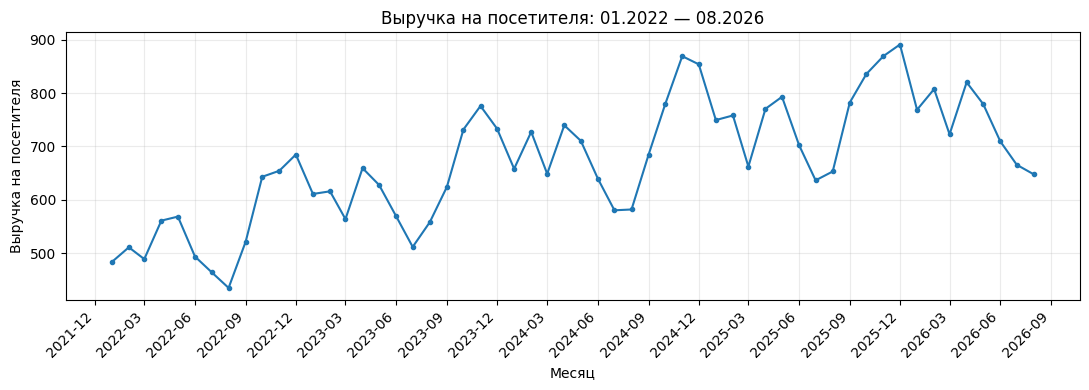

In [28]:
#Этот блок определяет универсальную функцию визуализации метрики по времени и применяет её ко всем девяти сетевым показателям.

def plot_metric(data, metric, percent=False, save_path=None):
    """
    Рисует линейный график метрики по месяцам.

    Параметры:
        data      — DataFrame с колонками "Месяц" и metric;
        metric    — название метрики (строкой), должно совпадать с именем столбца;
        percent   — если True, значения умножаются на 100 (для долей-метрик вроде конверсии);
        save_path — если задан, график сохраняется в файл (например, "plots/revenue.png").
    """
    # Создаём фигуру и ось. Работаем через fig, ax — так удобнее
    # настраивать отдельные элементы (даты, формат оси Y, сетку и т.д.).
    fig, ax = plt.subplots(figsize=(11, 4))

    # Если метрика — доля (например, конверсия 0.10 = 10%),
    # умножаем на 100, чтобы на оси Y были проценты, а не доли.
    y = data[metric] * 100 if percent else data[metric]

    # Линейный график по времени.
    # marker="o" с небольшим markersize — точки видны, но не «забивают» линию.
    ax.plot(data["Месяц"], y, marker="o", markersize=3, linewidth=1.5)

    # --- Автоматический период в заголовке ---
    # Берём минимальную и максимальную дату из данных.
    # strftime("%m.%Y") даёт компактный вид: "01.2022".
    first = data["Месяц"].min().strftime("%m.%Y")
    last = data["Месяц"].max().strftime("%m.%Y")
    ax.set_title(f"{metric}: {first} — {last}")

    # Подписи осей.
    ax.set_xlabel("Месяц")
    ax.set_ylabel(metric + (", %" if percent else ""))

    # --- Форматирование дат на оси X ---
    # Ставим метки раз в 3 месяца, чтобы подписи не слипались.
    # Формат "YYYY-MM" — привычный и однозначный.
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    # Наклоняем подписи на 45° для читаемости.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # --- Форматирование значений на оси Y ---
    # Функция добавляет пробел как разделитель разрядов.
    # Для процентов и мелких значений (например, длины чека) суффикс " %" не нужен —
    # его добавляет подпись оси. Здесь только разделитель разрядов.
    def thousands_formatter(x, _):
        if abs(x) >= 1000:
            return f"{x:,.0f}".replace(",", " ")
        return f"{x:.2f}".rstrip("0").rstrip(".")

    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    # Сетка с прозрачностью 0.25 — не отвлекает, но помогает читать значения.
    ax.grid(alpha=0.25)

    # Автоматическая подгонка отступов, чтобы подписи дат не обрезались.
    plt.tight_layout()

    # --- Опциональное сохранение в файл ---
    # dpi=150 и bbox_inches="tight" дают аккуратную картинку для вставки в отчёт.
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


# --- Строим графики для всех метрик ---
# Абсолютные метрики — без процентов.
plot_metric(network, "Выручка")
plot_metric(network, "Посетители")
plot_metric(network, "Чеки")
plot_metric(network, "Покупки")

# Конверсия — доля, поэтому percent=True: на оси Y будут проценты.
plot_metric(network, "Конверсия", percent=True)

# Относительные метрики — без процентов.
plot_metric(network, "Длина чека")
plot_metric(network, "Средняя цена")
plot_metric(network, "Средний чек")
plot_metric(network, "Выручка на посетителя")

## Что делает код в целом
Определяет функцию plot_metric, которая:

принимает DataFrame и имя метрики;

рисует линейный график метрики по времени;

умеет переводить доли в проценты (флаг percent=True);

подписывает оси и заголовок, добавляет сетку.

Вызывает её для каждой из девяти метрик, задавая percent=True только для конверсии.

Такой подход — «функция + вызовы» — предпочтительнее, чем копипаста одного и того же кода девять раз: если понадобится добавить подписи значений, изменить палитру или размер — правим одно место.

## Зачем это нужно
Единый шаблон визуализации даёт консистентную картину:

все графики одного размера;

одинаковый стиль сетки и подписей;

легко сравнивать метрики между собой;

можно быстро просмотреть всю динамику подряд.

## Как читать графики
Тренд. Растёт / падает / стабильна метрика на длинном горизонте.

Сезонность. Регулярные пики и спады с периодом 12 месяцев.

Аномалии. Разовые всплески или провалы — повод разобраться в причинах.

Связь между метриками. Если после просмотра всех графиков видно, что, например, Посетители и Выручка движутся синхронно, а Конверсия — в противофазе, это уже гипотеза для факторного анализа.

# 13. Что такое сезонность?

**Сезонность** — это закономерно повторяющееся изменение показателя, связанное с календарным периодом.

Для fashion retail сезонность может быть связана с:

- погодой;
- сменой коллекций;
- праздничными периодами;
- распродажами;
- началом и окончанием fashion-сезона;
- покупательским поведением.

Важно отличать:

- **тренд** — долгосрочное направление изменения;
- **сезонность** — повторяющийся календарный рисунок;
- **случайные колебания** — изменения без устойчивой повторяемой структуры.

# 14. Месячные сезонные коэффициенты

Для первого знакомства используем простой описательный коэффициент:

\[
K_m=
\frac{\text{среднее значение KPI в месяце }m}
{\text{среднее значение KPI за все месяцы}}
\]

Интерпретация:

- \(K=1.15\) — месяц примерно на 15% выше среднего;
- \(K=0.82\) — примерно на 18% ниже среднего;
- \(K\approx1.00\) — близок к среднему уровню.

Чтобы все календарные месяцы имели одинаковое число наблюдений, для расчёта коэффициентов используем **полные 2022–2025 годы**.

Это пока упрощённая описательная оценка сезонности, а не полноценная декомпозиция временного ряда.

In [30]:
#Этот блок вычисляет индекс сезонности для каждой сетевой метрики: во сколько раз среднее значение
#в конкретном месяце отклоняется от общего среднего за все полные годы.
# --- Отбираем только полные годы ---
# В данных есть 2022, 2023, 2024, 2025 (полные) и 2026 (неполный — до августа).
# Для корректного расчёта сезонности нужны только полные годы:
# если оставить неполный 2026, средние по месяцам будут смещены
# (например, для января-августа данные есть, для сентября-декабря — нет).
full_years = network[
    network["Месяц"].dt.year.isin([2022, 2023, 2024, 2025])
].copy()

# Вытаскиваем номер месяца (1..12) — он будет ключом группировки.
# Использовать номер, а не название, удобнее: сортировка 1..12 автоматическая,
# не нужно задавать порядок для строк.
full_years["Номер месяца"] = full_years["Месяц"].dt.month

# Словарь сопоставления номера месяца и короткого русского названия.
# Нужен только для красивого вывода в конце — расчёты идут по номерам.
month_names = {
    1: "Янв", 2: "Фев", 3: "Мар", 4: "Апр",
    5: "Май", 6: "Июн", 7: "Июл", 8: "Авг",
    9: "Сен", 10: "Окт", 11: "Ноя", 12: "Дек"
}

# --- Средние значения метрик по каждому календарному месяцу ---
# groupby("Номер месяца") даёт 12 групп (по одной на каждый месяц года).
# Внутри каждой группы усредняем метрики по всем годам: например,
# средняя выручка за январь = (янв-2022 + янв-2023 + янв-2024 + янв-2025) / 4.
# Результат — DataFrame 12×N: строки = месяцы (1..12), столбцы = метрики.
month_means = full_years.groupby("Номер месяца")[METRICS].mean()

# --- Общее среднее по всем полным годам ---
# Одна строка на каждую метрику: среднее по всей выборке (все месяцы × все годы).
# Это база для индекса сезонности: сравниваем поведение каждого месяца с этим уровнем.
overall_means = full_years[METRICS].mean()

# --- Индекс сезонности ---
# Делим среднее по месяцу на общее среднее — поэлементно, по столбцам.
# axis=1 означает: деление идёт по строкам, а значения `overall_means` берутся
# из столбцов (то есть каждый столбец делится на своё общее среднее).
# 
# Интерпретация:
#   = 1.00 — месяц "как обычно", совпадает с общим средним;
#   > 1.00 — месяц выше среднего (например, 1.20 = +20% к среднему);
#   < 1.00 — месяц ниже среднего (например, 0.85 = −15% к среднему).
season_idx = month_means.div(overall_means, axis=1)

# Меняем индекс с числового (1..12) на короткое название месяца.
# Делаем это последним шагом, чтобы все расчёты шли по числам
# (сохраняется естественный порядок 1..12), а вывод был читаемым.
season_idx.index = [month_names[m] for m in season_idx.index]

# Показываем результат, округляя до 3 знаков для удобства.
# Округление — только отображение, сам season_idx хранит полную точность.
display(season_idx.round(3))

,Выручка,Посетители,Чеки,Покупки,Конверсия,Длина чека,Средняя цена,Средний чек,Выручка на посетителя
Янв,0.852,0.910,0.864,0.844,0.950,0.978,0.999,0.989,0.948
Фев,0.755,0.769,0.839,0.851,1.089,1.013,0.879,0.902,0.990
Мар,0.951,1.061,0.954,0.896,0.893,0.939,1.050,0.998,0.896
Апр,0.923,0.898,0.921,0.898,1.023,0.975,1.020,1.007,1.035
Май,0.987,0.973,1.002,1.094,1.027,1.093,0.895,0.990,1.023
Июн,0.874,0.968,0.992,1.098,1.023,1.106,0.791,0.885,0.911
Июл,0.752,0.908,0.997,1.074,1.093,1.076,0.694,0.756,0.831
Авг,0.942,1.117,1.157,1.219,1.030,1.052,0.764,0.815,0.844
Сен,1.003,1.023,0.968,0.925,0.946,0.954,1.077,1.040,0.990
Окт,1.345,1.183,1.141,0.999,0.955,0.874,1.338,1.183,1.133


## Что делает код в целом
Отбирает только полные годы (2022–2025). Неполный 2026 исключён, чтобы не смещать средние по месяцам.

Добавляет номер месяца (1–12) для группировки.

Считает среднее значение каждой метрики по каждому календарному месяцу, усредняя по всем годам: например, «средний январь» = среднее из четырёх янвáрей.

Считает общее среднее по всем полным данным — базу для сравнения.

Вычисляет индекс сезонности как отношение: среднее по месяцу ÷ общее среднее.

Переименовывает индекс в короткие названия месяцев и выводит таблицу.

## Как читать таблицу season_idx

Таблица размером 12 × N (12 месяцев × число метрик). Каждое значение — индекс сезонности:

1.000 — в этом месяце метрика в среднем на своём обычном уровне.

1.150 — на 15% выше среднего (сезонный пик).

0.850 — на 15% ниже среднего (сезонный спад).

Пример интерпретации для типичного ритейла:

Выручка в декабре — обычно 1.2–1.5 (праздничный пик).

Выручка в январе-феврале — 0.8–0.9 (послепраздничный спад).

Посетители — похожая картина.

Средний чек и Средняя цена — часто менее сезонны, чем трафик.

Конверсия — может вести себя независимо (например, снижаться в праздники из-за «оконных шопперов»).

## Зачем это нужно
Понимание структуры данных. Прежде чем строить прогнозные модели, важно знать, какие месяцы сезонно «высокие» и «низкие».

Учёт сезонности в сравнениях. Если в марте выручка выросла к февралю, а сезонный индекс марта = 1.15 — часть роста объясняется сезонностью, а не реальным улучшением.

Декомпозиция и планирование. При построении бюджета на следующий год сезонные индексы помогают распределить годовые цели по месяцам.

Обнаружение аномалий. Если в каком-то году декабрь сильно выбивается из типичного индекса — стоит разбираться: акция, разовый скачок, ошибка в данных.

## 15. У какого KPI сезонность выражена сильнее?

Для простого сравнения введём амплитуду сезонных коэффициентов:


$$Amplitude=K_{max}-K_{min}$$


Чем больше диапазон между максимальным и минимальным сезонным коэффициентом, тем заметнее календарная сезонность показателя.

Это простая учебная мера, а не универсальный статистический тест сезонности.

In [11]:
season_strength = pd.DataFrame({
    "Min_K": season_idx.min(),
    "Max_K": season_idx.max()
})

season_strength["Амплитуда"] = (
    season_strength["Max_K"] - season_strength["Min_K"]
)

season_strength = season_strength.sort_values(
    "Амплитуда",
    ascending=False
)

display(season_strength.round(3))

,Min_K,Max_K,Амплитуда
Средняя цена,0.694,1.378,0.684
Выручка,0.752,1.372,0.621
Средний чек,0.756,1.290,0.534
Посетители,0.769,1.183,0.413
Покупки,0.844,1.219,0.375
Выручка на посетителя,0.831,1.201,0.369
Чеки,0.839,1.157,0.318
Длина чека,0.874,1.106,0.232
Конверсия,0.893,1.093,0.200


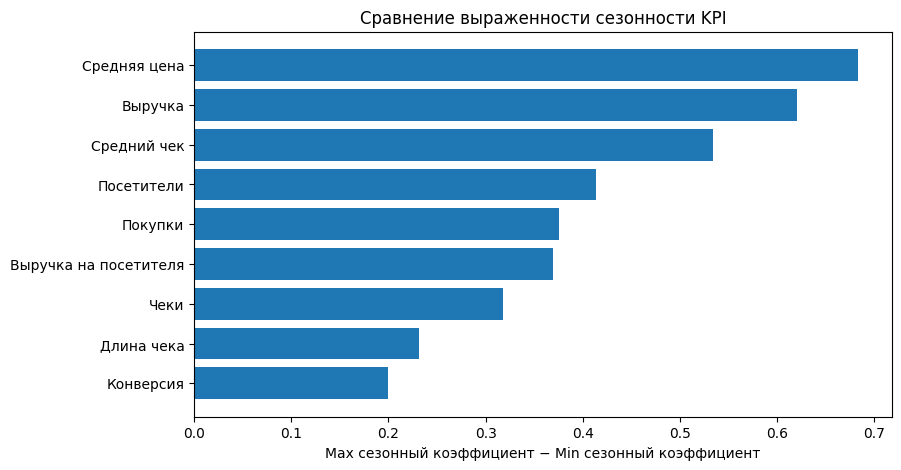

In [12]:
plt.figure(figsize=(9, 5))
plt.barh(
    season_strength.index[::-1],
    season_strength["Амплитуда"][::-1]
)
plt.xlabel("Max сезонный коэффициент − Min сезонный коэффициент")
plt.title("Сравнение выраженности сезонности KPI")
plt.show()

## 16. Графики месячных сезонных коэффициентов

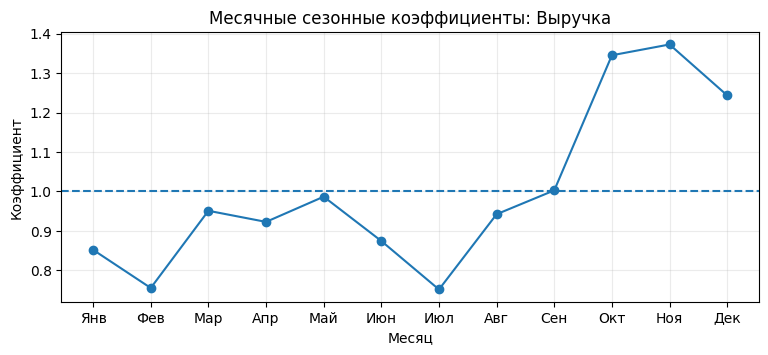

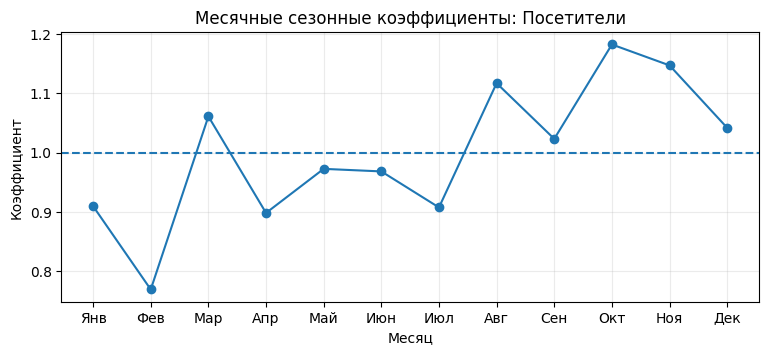

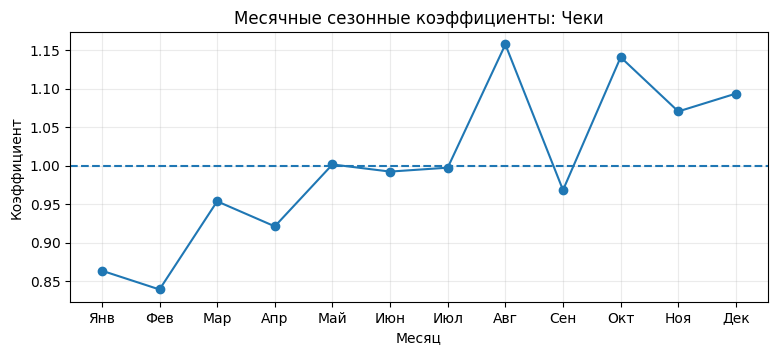

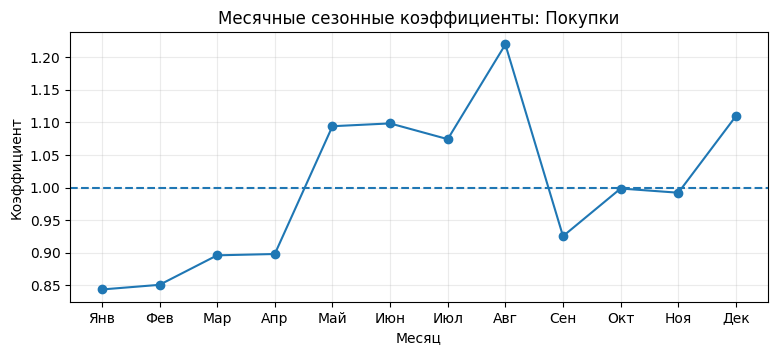

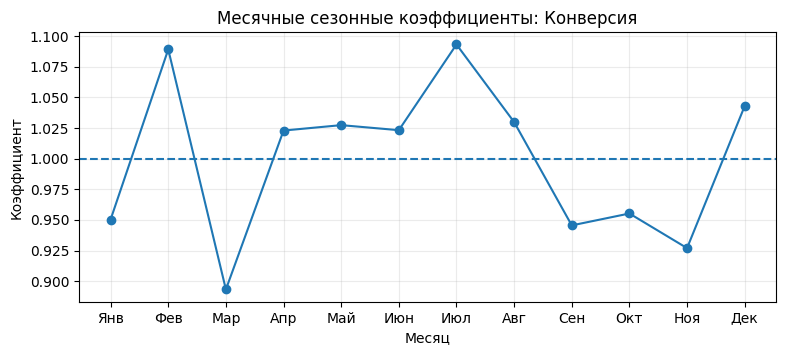

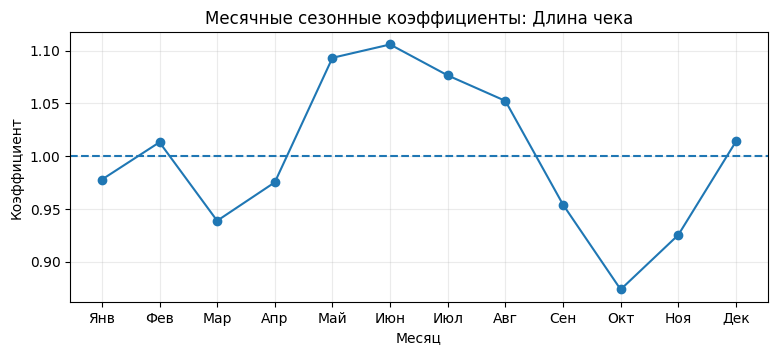

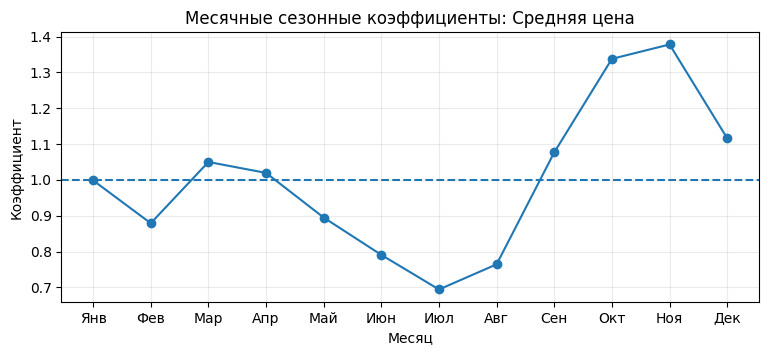

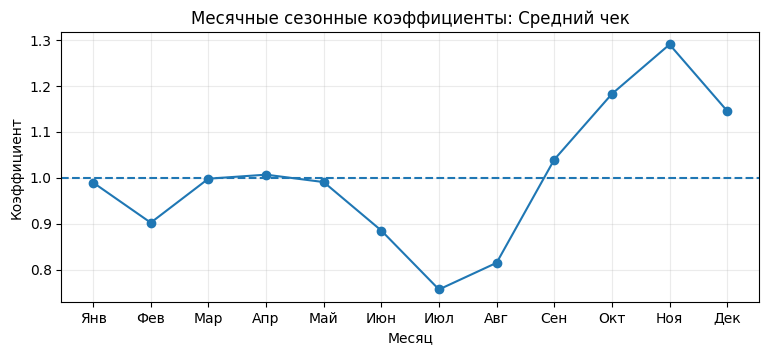

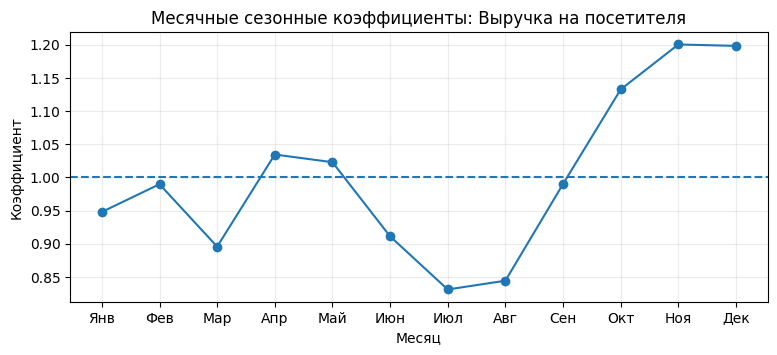

In [13]:
for metric in METRICS:
    plt.figure(figsize=(9, 3.5))
    plt.plot(
        season_idx.index,
        season_idx[metric],
        marker="o"
    )
    plt.axhline(1, linestyle="--")
    plt.title(f"Месячные сезонные коэффициенты: {metric}")
    plt.ylabel("Коэффициент")
    plt.xlabel("Месяц")
    plt.grid(alpha=0.25)
    plt.show()

### Вопросы для интерпретации

1. У какого показателя сезонность выражена особенно ярко?
2. Какие KPI наиболее стабильны по месяцам?
3. Совпадают ли сезонные пики выручки и посетителей?
4. Насколько сезонна средняя цена?
5. Может ли высокая вариативность выручки объясняться сезонностью?

Ответы нужно формулировать **по рассчитанным данным**, а не по общим представлениям о fashion retail.

# 17. Fashion-сезоны S и W

В розничной торговле одеждой календарный год не всегда является основным бизнес-периодом.

В нашем курсе используем:

### Сезон S
**март — август**

### Сезон W
**сентябрь — февраль**

Обозначение сезона:

- `S22` = март 2022 — август 2022;
- `W22` = сентябрь 2022 — февраль 2023;
- `S23` = март 2023 — август 2023;
- `W23` = сентябрь 2023 — февраль 2024;
- и т.д.

Таким образом, год W определяется по **сентябрю**, с которого начинается сезон.

In [14]:
def fashion_season(date):
    year = date.year
    month = date.month

    if 3 <= month <= 8:
        return f"S{str(year)[-2:]}"
    elif month >= 9:
        return f"W{str(year)[-2:]}"
    else:
        # Январь-февраль относятся к W, начавшемуся в предыдущем году
        return f"W{str(year - 1)[-2:]}"

network["Сезон"] = network["Месяц"].apply(fashion_season)

display(network[["Месяц", "Сезон"]].head(16))

,Месяц,Сезон
0,2022-01-01,W21
1,2022-02-01,W21
2,2022-03-01,S22
3,2022-04-01,S22
4,2022-05-01,S22
5,2022-06-01,S22
6,2022-07-01,S22
7,2022-08-01,S22
8,2022-09-01,W22
9,2022-10-01,W22


## 18. Полные и неполные сезоны

Наша база начинается в январе 2022 и заканчивается августом 2026.

Поэтому:

- `W21` представлен только январём–февралём 2022 — **неполный**, исключаем;
- `S22` — полный;
- `W22` — полный;
- ...
- `W25` — полный;
- `S26` — полный.

При сравнении сезонов используем только периоды, содержащие все 6 месяцев.

In [15]:
season_month_count = (
    network.groupby("Сезон")["Месяц"]
    .nunique()
    .sort_index()
)

display(season_month_count.to_frame("Количество месяцев"))

full_seasons = season_month_count[
    season_month_count == 6
].index.tolist()

print("Полные сезоны:", full_seasons)

,Количество месяцев
Сезон,
S22,6
S23,6
S24,6
S25,6
S26,6
W21,2
W22,6
W23,6
W24,6


Полные сезоны: ['S22', 'S23', 'S24', 'S25', 'S26', 'W22', 'W23', 'W24', 'W25']


# 19. Правильный расчёт KPI по сезонам

Здесь снова важно не брать простое среднее месячных относительных KPI.

Сначала суммируем:

- выручку;
- посетителей;
- чеки;
- покупки.

Затем заново рассчитываем:

- конверсию;
- длину чека;
- среднюю цену;
- средний чек;
- выручку на посетителя.

In [16]:
season_base = (
    network[network["Сезон"].isin(full_seasons)]
    .groupby("Сезон", as_index=False)
    .agg(
        Выручка=("Выручка", "sum"),
        Посетители=("Посетители", "sum"),
        Чеки=("Чеки", "sum"),
        Покупки=("Покупки", "sum")
    )
)

season_base["Конверсия"] = (
    season_base["Чеки"] / season_base["Посетители"]
)
season_base["Длина чека"] = (
    season_base["Покупки"] / season_base["Чеки"]
)
season_base["Средняя цена"] = (
    season_base["Выручка"] / season_base["Покупки"]
)
season_base["Средний чек"] = (
    season_base["Выручка"] / season_base["Чеки"]
)
season_base["Выручка на посетителя"] = (
    season_base["Выручка"] / season_base["Посетители"]
)

display(season_base)

,Сезон,Выручка,Посетители,Чеки,Покупки,Конверсия,Длина чека,Средняя цена,Средний чек,Выручка на посетителя
0,S22,1042735383,2078551,157425,453321,0.075738,2.879600,2300.214160,6623.696255,501.664565
1,S23,1128513143,1945589,158742,469152,0.081591,2.955437,2405.431807,7109.102462,580.036762
2,S24,1055855866,1630265,138517,415701,0.084966,3.001083,2539.940645,7622.572435,647.659041
3,S25,942345702,1346852,112502,338439,0.083530,3.008293,2784.388625,8376.257329,699.665369
4,S26,865572833,1193847,94567,278485,0.079212,2.944843,3108.148852,9153.011442,725.028277
5,W22,1302180957,2088010,159401,427142,0.076341,2.679670,3048.590298,8169.214478,623.646897
6,W23,1367349244,1920009,153543,423443,0.079970,2.757814,3229.122323,8905.318015,712.157726
7,W24,1208830690,1538943,126238,343200,0.082029,2.718674,3522.233945,9575.806730,785.494128
8,W25,1144219019,1377319,109126,300809,0.079231,2.756529,3803.805800,10485.301569,830.758175


# 20. Сравниваем S только с S, W только с W

Для fashion retail корректнее оценивать динамику:

\[
S23 \; vs \; S22
\]

\[
S24 \; vs \; S23
\]

и отдельно:

\[
W23 \; vs \; W22
\]

\[
W24 \; vs \; W23
\]

Сравнение S с W отвечает уже на другой вопрос — о различии сезонной структуры бизнеса.

In [17]:
season_dynamics = season_base.copy()

season_dynamics["Тип"] = season_dynamics["Сезон"].str[0]
season_dynamics["Год"] = season_dynamics["Сезон"].str[1:].astype(int)

season_dynamics = season_dynamics.sort_values(["Тип", "Год"])

for metric in METRICS:
    season_dynamics[f"{metric}_YoY_%"] = (
        season_dynamics
        .groupby("Тип")[metric]
        .pct_change() * 100
    )

display(
    season_dynamics[
        [
            "Сезон",
            "Выручка",
            "Выручка_YoY_%",
            "Посетители",
            "Посетители_YoY_%",
            "Конверсия",
            "Конверсия_YoY_%",
            "Средняя цена",
            "Средняя цена_YoY_%"
        ]
    ].round(3)
)

,Сезон,Выручка,Выручка_YoY_%,Посетители,Посетители_YoY_%,Конверсия,Конверсия_YoY_%,Средняя цена,Средняя цена_YoY_%
0,S22,1042735383,NaN,2078551,NaN,0.076,NaN,2300.214,NaN
1,S23,1128513143,8.226,1945589,-6.397,0.082,7.728,2405.432,4.574
2,S24,1055855866,-6.438,1630265,-16.207,0.085,4.137,2539.941,5.592
3,S25,942345702,-10.751,1346852,-17.384,0.084,-1.690,2784.389,9.624
4,S26,865572833,-8.147,1193847,-11.360,0.079,-5.169,3108.149,11.628
5,W22,1302180957,NaN,2088010,NaN,0.076,NaN,3048.590,NaN
6,W23,1367349244,5.005,1920009,-8.046,0.080,4.753,3229.122,5.922
7,W24,1208830690,-11.593,1538943,-19.847,0.082,2.575,3522.234,9.077
8,W25,1144219019,-5.345,1377319,-10.502,0.079,-3.411,3803.806,7.994


## 21. Визуальная динамика S и W

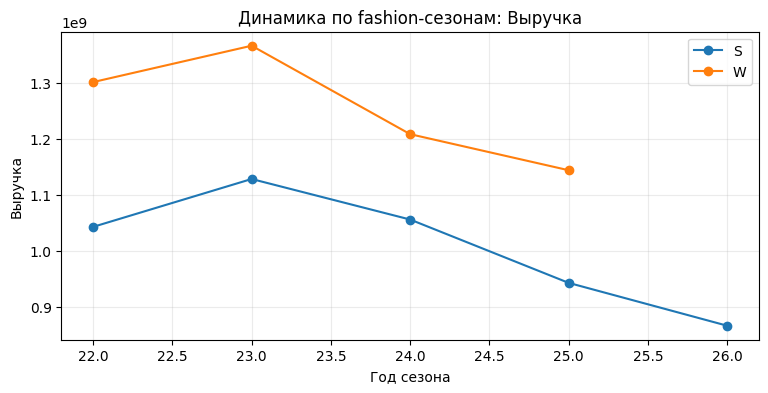

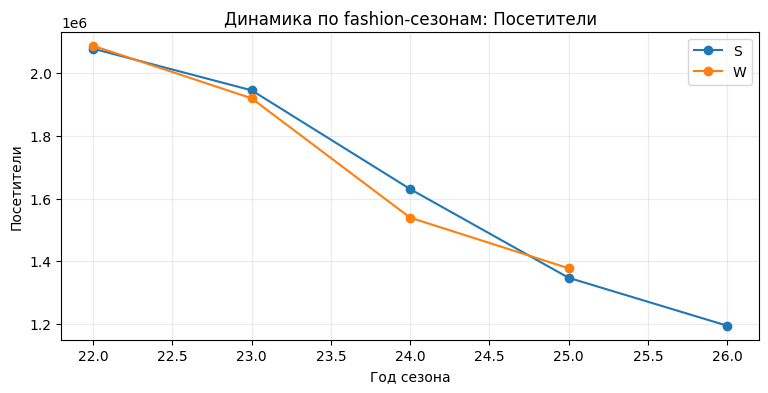

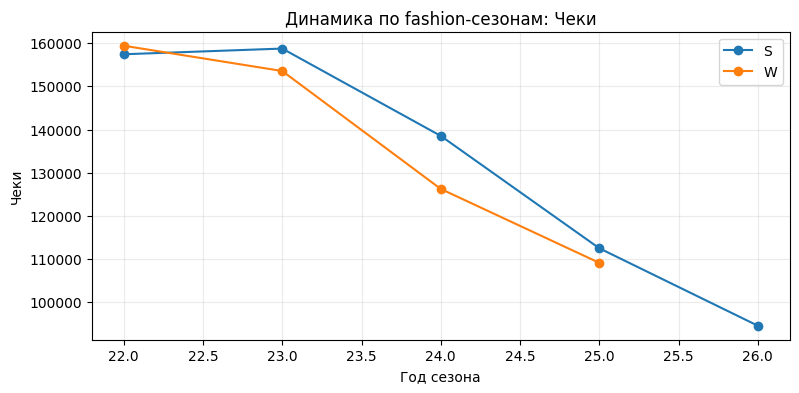

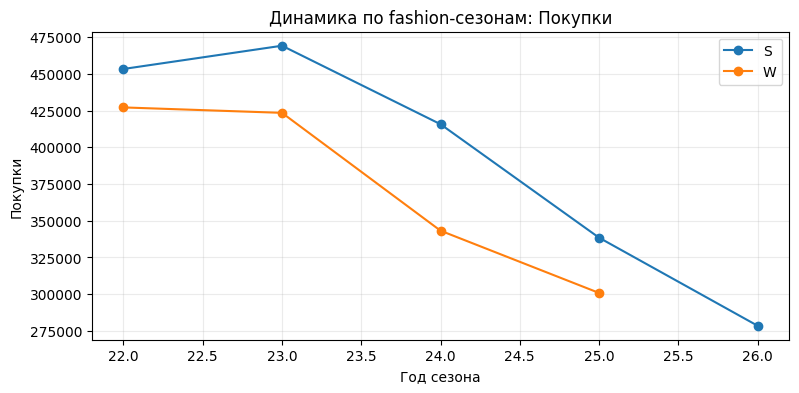

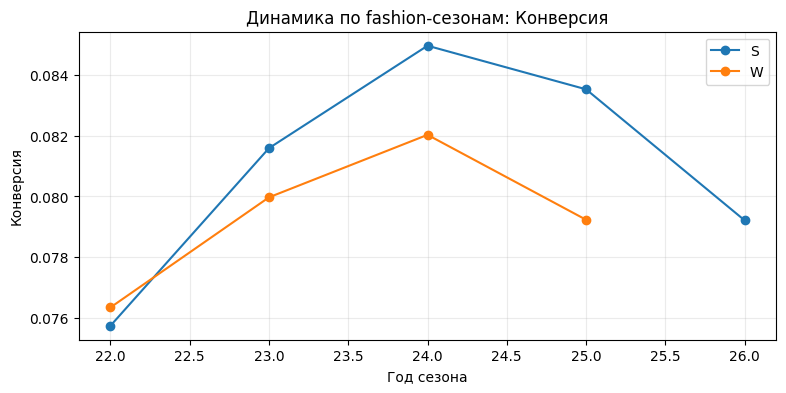

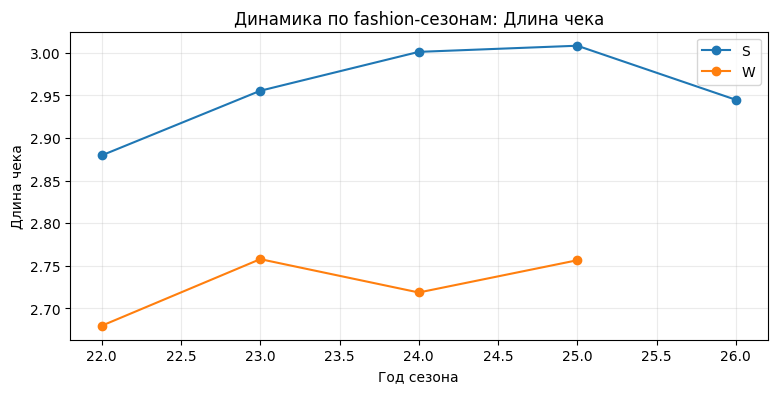

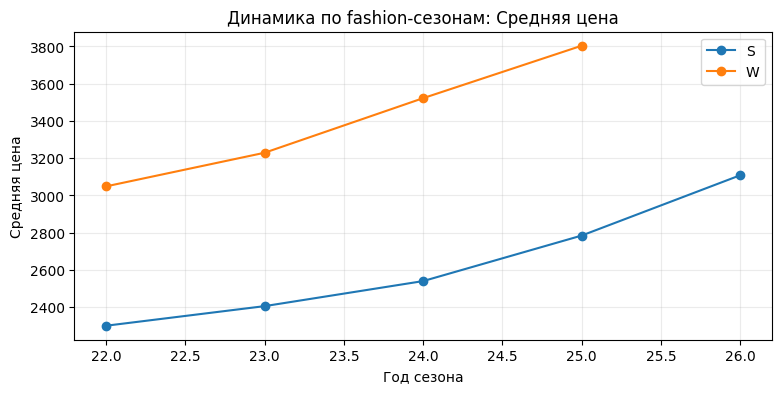

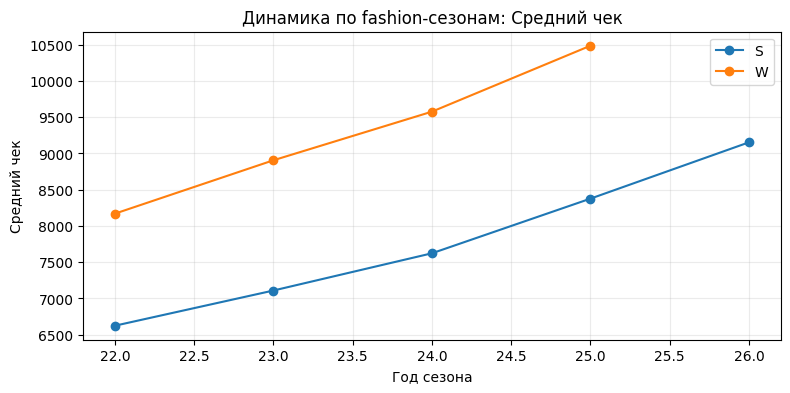

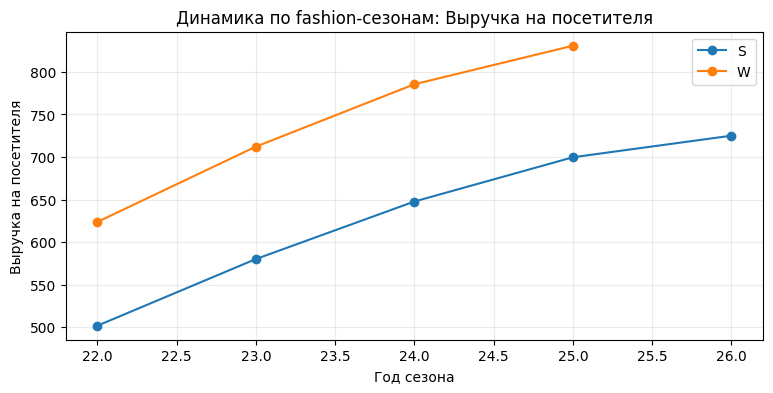

In [18]:
for metric in METRICS:
    temp = season_dynamics.copy()

    plt.figure(figsize=(9, 4))

    for season_type in ["S", "W"]:
        part = temp[temp["Тип"] == season_type]
        plt.plot(
            part["Год"],
            part[metric],
            marker="o",
            label=season_type
        )

    plt.title(f"Динамика по fashion-сезонам: {metric}")
    plt.xlabel("Год сезона")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

# 22. Доли S и W в полном fashion-цикле

Fashion-цикл будем определять как:

\[
S_{yy}+W_{yy}
\]

Например:

\[
S22 + W22
\]

соответствует периоду:

**март 2022 — февраль 2023**.

Рассчитаем доли S и W:

- в выручке;
- в посетителях.

Это позволит увидеть, одинаково ли сезоны формируют поток посетителей и денежный результат.

In [19]:
cycle = season_base.copy()
cycle["Тип"] = cycle["Сезон"].str[0]
cycle["Год"] = cycle["Сезон"].str[1:].astype(int)

cycle_pivot = cycle.pivot(
    index="Год",
    columns="Тип",
    values=["Выручка", "Посетители"]
)

# Оставляем только годы, где есть и S, и W
cycle_pivot = cycle_pivot.dropna()

result_cycle = pd.DataFrame(index=cycle_pivot.index)

result_cycle["S_Выручка"] = cycle_pivot[("Выручка", "S")]
result_cycle["W_Выручка"] = cycle_pivot[("Выручка", "W")]
result_cycle["Доля_S_выручка"] = (
    result_cycle["S_Выручка"]
    / (result_cycle["S_Выручка"] + result_cycle["W_Выручка"])
)
result_cycle["Доля_W_выручка"] = 1 - result_cycle["Доля_S_выручка"]

result_cycle["S_Посетители"] = cycle_pivot[("Посетители", "S")]
result_cycle["W_Посетители"] = cycle_pivot[("Посетители", "W")]
result_cycle["Доля_S_посетители"] = (
    result_cycle["S_Посетители"]
    / (result_cycle["S_Посетители"] + result_cycle["W_Посетители"])
)
result_cycle["Доля_W_посетители"] = 1 - result_cycle["Доля_S_посетители"]

result_cycle.index = [
    f"S{str(y).zfill(2)} + W{str(y).zfill(2)}"
    for y in result_cycle.index
]

display(result_cycle.round(4))

,S_Выручка,W_Выручка,Доля_S_выручка,Доля_W_выручка,S_Посетители,W_Посетители,Доля_S_посетители,Доля_W_посетители
S22 + W22,1.042735e+09,1.302181e+09,0.4447,0.5553,2078551.0,2088010.0,0.4989,0.5011
S23 + W23,1.128513e+09,1.367349e+09,0.4522,0.5478,1945589.0,1920009.0,0.5033,0.4967
S24 + W24,1.055856e+09,1.208831e+09,0.4662,0.5338,1630265.0,1538943.0,0.5144,0.4856
S25 + W25,9.423457e+08,1.144219e+09,0.4516,0.5484,1346852.0,1377319.0,0.4944,0.5056


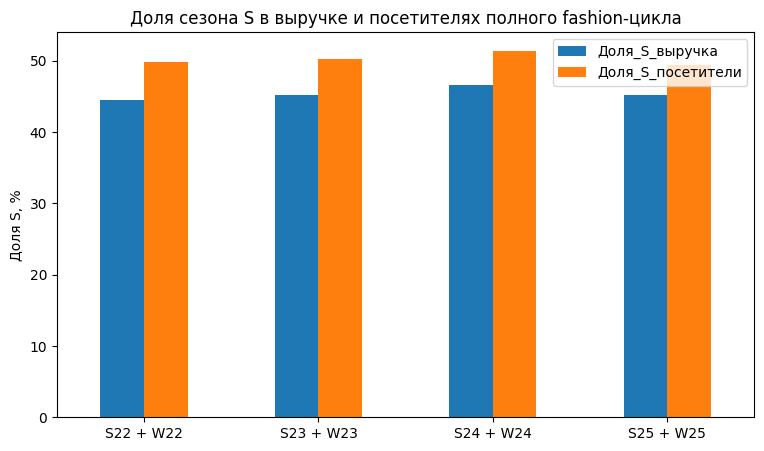

In [20]:
plot_share = result_cycle[
    [
        "Доля_S_выручка",
        "Доля_S_посетители"
    ]
] * 100

plot_share.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Доля S, %")
plt.title("Доля сезона S в выручке и посетителях полного fashion-цикла")
plt.xticks(rotation=0)
plt.show()

## 23. Как интерпретировать различие долей?

Предположим:

\[
Доля_S^{Revenue}
>
Доля_S^{Visitors}
\]

Это означает, что сезон S формирует большую долю выручки, чем его доля в потоке посетителей.

Одна из возможных причин — более высокая:

\[
Выручка\ на\ посетителя
\]

Но затем этот показатель необходимо разложить:

\[
Выручка\ на\ посетителя
=
Конверсия
\times
Длина\ чека
\times
Средняя\ цена
\]

Так мы переходим от простого описания к **факторному мышлению**.

# 24. Что мы пока сознательно НЕ делаем

В этом уроке мы не применяем:

- t-тест;
- Mann–Whitney;
- Wilcoxon;
- ANOVA;
- p-value;
- доверительные интервалы;
- формальные тесты сезонности;
- декомпозицию временного ряда;
- прогнозирование.

Сначала нужно научиться правильно рассчитывать и описывать показатели.

Статистический вывод начнётся в следующих уроках.

# 25. Итоги урока

После урока необходимо уметь объяснить:

### 1. Какие KPI можно суммировать
- Выручка
- Посетители
- Чеки
- Покупки

### 2. Какие KPI нужно пересчитывать
- Конверсия
- Длина чека
- Средняя цена
- Средний чек
- Выручка на посетителя

### 3. Различие между
- средним;
- взвешенным средним;
- медианой.

### 4. Что характеризуют
- дисперсия;
- стандартное отклонение;
- коэффициент вариации.

### 5. Почему нельзя анализировать вариативность без учёта сезонности.

### 6. Как рассчитываются простые месячные коэффициенты сезонности.

### 7. Как в fashion retail определяются сезоны
- S: март–август;
- W: сентябрь–февраль.

### 8. Почему S нужно сравнивать с S, а W — с W.

### 9. Как связаны основные KPI:

\[
Выручка
=
Посетители
\times
Конверсия
\times
Длина\ чека
\times
Средняя\ цена
\]

# 26. Практическое задание

Используя книгу `Retail_50_Stores_Synthetic_v1.xlsx`:

### Часть 1. Агрегация KPI
1. Получите месячные показатели всей сети.
2. Рассчитайте 9 основных KPI.
3. Проверьте формулы расчётных показателей.

### Часть 2. Описательная статистика
4. Для каждого KPI рассчитайте:
   - среднее;
   - медиану;
   - дисперсию;
   - стандартное отклонение;
   - коэффициент вариации.
5. Определите, какие показатели наиболее изменчивы.

### Часть 3. Сезонность
6. Постройте месячную динамику каждого KPI.
7. Рассчитайте сезонные коэффициенты по полным 2022–2025 годам.
8. Определите KPI с наиболее и наименее выраженной сезонностью.

### Часть 4. Fashion-сезоны
9. Сформируйте сезоны S и W.
10. Рассчитайте все 9 KPI по каждому полному сезону.
11. Рассчитайте динамику S/S и W/W.
12. Рассчитайте доли S и W в:
   - выручке;
   - посетителях.
13. Объясните различия между долями выручки и посетителей через показатель «Выручка на посетителя».

### Финальный вопрос
Какой из девяти KPI вы считаете наиболее полезным для интегральной оценки эффективности посетительского потока и почему?

# 27. Контрольные вопросы

### Вопрос 1
Можно ли рассчитать конверсию за два месяца как простое среднее месячных конверсий?

**Ответ:** не всегда. Если число посетителей отличается, нужно использовать агрегированные чеки и посетителей либо эквивалентное взвешенное среднее.

---

### Вопрос 2
Какой показатель является весом при расчёте общей средней цены?

**Ответ:** количество покупок.

---

### Вопрос 3
Какой показатель лучше использовать для сравнения относительной изменчивости выручки и конверсии?

**Ответ:** коэффициент вариации.

---

### Вопрос 4
Если среднее заметно выше медианы, что это может означать?

**Ответ:** возможную правостороннюю асимметрию или влияние высоких значений/пиков.

---

### Вопрос 5
Почему январь–февраль 2022 нельзя использовать как самостоятельный W-сезон?

**Ответ:** это только два последних месяца сезона W21; сезон неполный.

---

### Вопрос 6
Как правильно сравнивать fashion-сезоны?

**Ответ:** S с S предыдущего года и W с W предыдущего года.

---

### Вопрос 7
Какая формула связывает выручку с четырьмя основными драйверами?

\[
Выручка
=
Посетители
\times
Конверсия
\times
Длина\ чека
\times
Средняя\ цена
\]

# Следующий урок

## Урок 2. Генеральная совокупность, выборка и единица наблюдения

После того как мы научились правильно **описывать данные**, следующий вопрос:

> На основании каких наблюдений мы можем делать статистические выводы?

Разберём:

- генеральную совокупность;
- выборку;
- единицу наблюдения;
- независимость;
- связанные и независимые наблюдения;
- почему строка таблицы не всегда является независимым статистическим наблюдением.

$$
\text{Длина чека} = \frac{\text{Покупки}}{\text{Чеки}}
$$